In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.lines as mlines
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
import pandas as pd

# 1. Obtenemos el ID del documento y el GID de la hoja específica
# De tu enlace original: gid=737168441
file_id = "18CTZg-1wp7WimorghISY78Y_JwRygvjy"
gid = "793455770"

# 2. Creamos la URL de exportación a CSV
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv&gid={gid}"

# 3. Leemos con read_csv (aquí NO se usa sheet_name)
journal_df = pd.read_csv(url)

# Figure 3 Journal Citation Network

In [3]:
# Instala python-louvain si hace falta
!pip -q install python-louvain

import pandas as pd
import networkx as nx

# Import robusto de Louvain
try:
    import community.community_louvain as community_louvain
except Exception:
    import community as community_louvain

def create_journal_citation_graph(journal_df, remove_self_loops=True, random_state=42):
    df = journal_df[["source_title_main", "source_title_ref"]].copy()

    for c in ["source_title_main", "source_title_ref"]:
        df[c] = df[c].astype(str).str.strip()
        df.loc[df[c].str.lower().isin(["", "nan", "none", "null"]), c] = pd.NA

    df = df.dropna(subset=["source_title_main", "source_title_ref"])

    if remove_self_loops:
        df = df[df["source_title_main"] != df["source_title_ref"]]

    df["u"] = df[["source_title_main", "source_title_ref"]].min(axis=1)
    df["v"] = df[["source_title_main", "source_title_ref"]].max(axis=1)

    edge_weights = (
        df.groupby(["u", "v"], as_index=False)
          .size()
          .rename(columns={"size": "weight"})
    )

    G = nx.from_pandas_edgelist(
        edge_weights,
        source="u",
        target="v",
        edge_attr="weight",
        create_using=nx.Graph()
    )

    if G.number_of_nodes() == 0:
        return G

    largest_component = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_component).copy()

    degrees = dict(G.degree())
    nx.set_node_attributes(G, degrees, "degree")

    communities = community_louvain.best_partition(G, random_state=random_state)

    community_sizes = {}
    for node, comm in communities.items():
        community_sizes[comm] = community_sizes.get(comm, 0) + 1

    sorted_communities = sorted(community_sizes, key=community_sizes.get, reverse=True)
    community_mapping = {old_comm: new_idx + 1 for new_idx, old_comm in enumerate(sorted_communities)}
    updated_communities = {node: community_mapping[comm] for node, comm in communities.items()}
    nx.set_node_attributes(G, updated_communities, "community")

    return G

journal_citation_graph_weighted_tbl_small = create_journal_citation_graph(journal_df)
print(
    f"Nodes: {journal_citation_graph_weighted_tbl_small.number_of_nodes()} | "
    f"Edges: {journal_citation_graph_weighted_tbl_small.number_of_edges()}"
)


Nodes: 3279 | Edges: 7655


In [4]:
# --- Export for Gephi ---
import pandas as pd
import networkx as nx

G = journal_citation_graph_weighted_tbl_small

# 1) GEXF (keeps node + edge attributes like degree/community/weight)
nx.write_gexf(G, "journal_citation_graph_weighted.gexf")

# 2) Edges CSV for Gephi
edges_df = pd.DataFrame(
    [(u, v, d.get("weight", 1)) for u, v, d in G.edges(data=True)],
    columns=["Source", "Target", "Weight"]
)
edges_df.to_csv("journal_citation_edges_weighted.csv", index=False)

# 3) Nodes CSV for Gephi
nodes_df = pd.DataFrame(
    [
        (n, n, G.nodes[n].get("degree", 0), G.nodes[n].get("community", None))
        for n in G.nodes()
    ],
    columns=["Id", "Label", "degree", "community"]
)
nodes_df.to_csv("journal_citation_nodes.csv", index=False)

print("Exported:")
print("- journal_citation_graph_weighted.gexf")
print("- journal_citation_edges_weighted.csv")
print("- journal_citation_nodes.csv")


Exported:
- journal_citation_graph_weighted.gexf
- journal_citation_edges_weighted.csv
- journal_citation_nodes.csv


In [5]:
import networkx as nx
import pandas as pd

def top_nodes_from_top3_clusters(G, top_clusters=3, top_nodes_per_cluster=10):
    # DataFrame de nodos con comunidad y grado
    nodes_data = []
    for n, attrs in G.nodes(data=True):
        nodes_data.append({
            "node": n,
            "community": attrs.get("community", None),
            "degree": G.degree(n)
        })
    nodes_df = pd.DataFrame(nodes_data).dropna(subset=["community"])

    # 1) Seleccionar los 3 clusters más grandes
    cluster_sizes = (
        nodes_df.groupby("community")["node"]
        .count()
        .sort_values(ascending=False)
    )
    top3 = cluster_sizes.head(top_clusters).index.tolist()

    # 2) Top 10 nodos por grado en cada cluster
    selected_nodes = []
    for c in top3:
        sub = nodes_df[nodes_df["community"] == c].sort_values("degree", ascending=False)
        selected_nodes.extend(sub.head(top_nodes_per_cluster)["node"].tolist())

    selected_nodes = list(dict.fromkeys(selected_nodes))  # quitar duplicados preservando orden
    return selected_nodes, top3

def build_reduced_graph_for_plot(G, selected_nodes):
    # 3) Subgrafo inducido
    H = G.subgraph(selected_nodes).copy()

    # Si quieres asegurar conectividad visual mínima, puedes quitar aislados:
    H.remove_nodes_from(list(nx.isolates(H)))
    return H

# Uso
selected_nodes, top3_clusters = top_nodes_from_top3_clusters(
    journal_citation_graph_weighted_tbl_small,
    top_clusters=3,
    top_nodes_per_cluster=10
)

H_plot = build_reduced_graph_for_plot(journal_citation_graph_weighted_tbl_small, selected_nodes)

print("Top 3 clusters:", top3_clusters)
print("Selected nodes:", len(selected_nodes))
print("Reduced graph -> Nodes:", H_plot.number_of_nodes(), "Edges:", H_plot.number_of_edges())


Top 3 clusters: [1, 2, 3]
Selected nodes: 30
Reduced graph -> Nodes: 30 Edges: 234


# Figure 3a - Country Collaboration

Top communities: [1, 2, 3]
Reduced graph -> Nodes: 30 | Edges: 162


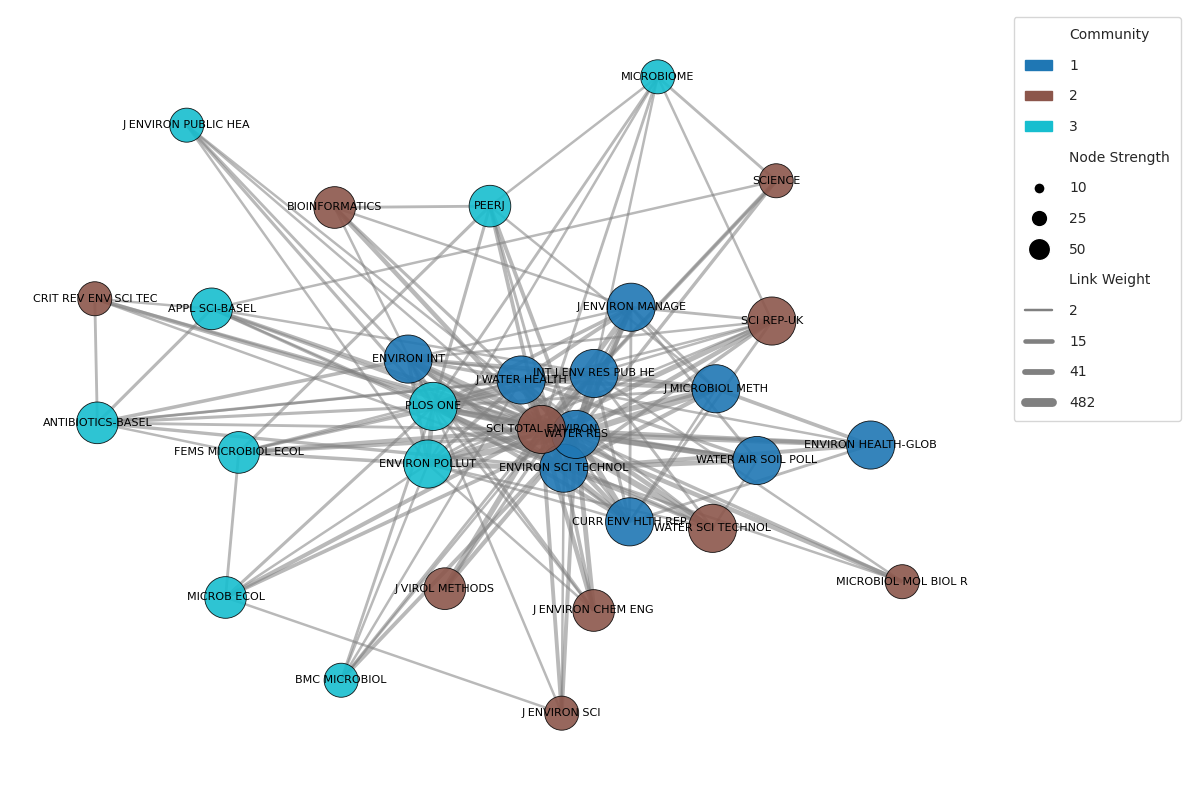

In [10]:
# --- Figure with top journals by weighted_degree + minimum citations ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Input graph from your previous step
G = journal_citation_graph_weighted_tbl_small

# -----------------------------
# Parameters (tune if needed)
# -----------------------------
TOP_COMMUNITIES = 3
TOP_NODES_PER_COMMUNITY = 10
MIN_NODE_STRENGTH = 10      # minimum weighted degree to be considered influential
MIN_EDGE_WEIGHT = 2         # keep only edges with at least this citation count

# 1) Build node table
node_df = pd.DataFrame(
    [
        {
            "node": n,
            "community": G.nodes[n].get("community"),
            "degree": G.degree(n),
            "strength": G.degree(n, weight="weight"),
        }
        for n in G.nodes()
    ]
).dropna(subset=["community"])

# 2) Top 3 largest communities
top_communities = (
    node_df.groupby("community")["node"]
    .count()
    .sort_values(ascending=False)
    .head(TOP_COMMUNITIES)
    .index
    .tolist()
)

# 3) Select top journals by strength within each community
selected_nodes = []

for comm in top_communities:
    sub = node_df[node_df["community"] == comm].copy()
    sub = sub[sub["strength"] >= MIN_NODE_STRENGTH]
    sub = sub.sort_values("strength", ascending=False).head(TOP_NODES_PER_COMMUNITY)
    selected_nodes.extend(sub["node"].tolist())

selected_nodes = list(dict.fromkeys(selected_nodes))

# 4) Reduced subgraph
H = G.subgraph(selected_nodes).copy()

# 5) Keep only meaningful citation links
to_remove = [
    (u, v)
    for u, v, d in H.edges(data=True)
    if d.get("weight", 1) < MIN_EDGE_WEIGHT
]

H.remove_edges_from(to_remove)

# Remove isolated nodes after edge filtering
H.remove_nodes_from(list(nx.isolates(H)))

print(f"Top communities: {top_communities}")
print(f"Reduced graph -> Nodes: {H.number_of_nodes()} | Edges: {H.number_of_edges()}")

# 6) Layout
pos = nx.spring_layout(H, seed=42, k=0.8)

# 7) Visual mappings
communities_set = sorted(set(nx.get_node_attributes(H, "community").values()))
cmap = plt.get_cmap("tab10", len(communities_set))

community_to_rgba = {
    c: cmap(communities_set.index(c))
    for c in communities_set
}

node_strength = dict(H.degree(weight="weight"))

def map_strength_to_size(s):
    """
    Matplotlib node size.
    These values are used in the exported SVG figure.
    """
    if s < 10:
        return 300
    elif s < 25:
        return 600
    elif s < 50:
        return 900
    return 1200

def map_strength_to_gephi_size(s):
    """
    Gephi node size.
    Gephi uses a different visual scale than Matplotlib.
    This keeps the same relative size logic but avoids extremely large nodes.
    """
    if s < 10:
        return 12
    elif s < 25:
        return 20
    elif s < 50:
        return 28
    return 36

def map_weight_to_width(w):
    return 0.8 + 0.9 * np.log1p(max(w, 1))

def rgba_to_gephi_color(rgba):
    """
    Converts Matplotlib RGBA colors, in 0-1 scale,
    to Gephi GEXF color format.
    """
    r, g, b, a = rgba
    return {
        "r": int(round(r * 255)),
        "g": int(round(g * 255)),
        "b": int(round(b * 255)),
        "a": float(a)
    }

def rgba_to_hex(rgba):
    """
    Optional readable color attribute.
    Useful if you want to inspect colors in Gephi's Data Laboratory.
    """
    r, g, b, a = rgba
    return "#{:02x}{:02x}{:02x}".format(
        int(round(r * 255)),
        int(round(g * 255)),
        int(round(b * 255))
    )

node_colors = [
    community_to_rgba[H.nodes[n]["community"]]
    for n in H.nodes()
]

node_sizes = [
    map_strength_to_size(node_strength.get(n, 0))
    for n in H.nodes()
]

edge_widths = [
    map_weight_to_width(H[u][v].get("weight", 1))
    for u, v in H.edges()
]

# 8) Add Gephi visual attributes
# This is the key section: Gephi reads size/color/position from the "viz" attribute.
for n in H.nodes():
    comm = H.nodes[n]["community"]
    strength = float(node_strength.get(n, 0))
    rgba = community_to_rgba[comm]

    gephi_color = rgba_to_gephi_color(rgba)
    gephi_size = float(map_strength_to_gephi_size(strength))

    H.nodes[n]["label"] = str(n)
    H.nodes[n]["strength"] = strength
    H.nodes[n]["gephi_size"] = gephi_size
    H.nodes[n]["color_hex"] = rgba_to_hex(rgba)

    H.nodes[n]["viz"] = {
        "color": gephi_color,
        "size": gephi_size,
        "position": {
            "x": float(pos[n][0] * 1000),
            "y": float(pos[n][1] * 1000),
            "z": 0.0
        }
    }

# Optional: also export edge thickness for Gephi
for u, v, d in H.edges(data=True):
    w = float(d.get("weight", 1))
    d["gephi_width"] = float(map_weight_to_width(w))
    d["viz"] = {
        "thickness": float(map_weight_to_width(w))
    }

# 9) Draw figure
plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(
    H, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9,
    linewidths=0.6,
    edgecolors="black"
)

nx.draw_networkx_edges(
    H, pos,
    width=edge_widths,
    alpha=0.55,
    edge_color="gray"
)

nx.draw_networkx_labels(
    H, pos,
    labels={n: n for n in H.nodes()},
    font_size=8,
    font_color="black"
)

# 10) Legends
community_legend = [Line2D([], [], color="none", label="Community")] + [
    Patch(color=community_to_rgba[c], label=str(c))
    for c in communities_set
]

strength_legend = [
    Line2D([], [], color="none", label="Node Strength"),
    Line2D([0], [0], marker="o", color="w", label="10", markerfacecolor="black", markersize=8),
    Line2D([0], [0], marker="o", color="w", label="25", markerfacecolor="black", markersize=12),
    Line2D([0], [0], marker="o", color="w", label="50", markerfacecolor="black", markersize=16),
]

weights = [H[u][v].get("weight", 1) for u, v in H.edges()]
unique_weights = sorted(set(int(w) for w in weights))

if len(unique_weights) >= 4:
    w_sel = [
        unique_weights[0],
        unique_weights[len(unique_weights) // 3],
        unique_weights[2 * len(unique_weights) // 3],
        unique_weights[-1],
    ]
else:
    w_sel = unique_weights

edge_legend = [Line2D([], [], color="none", label="Link Weight")] + [
    Line2D([0], [0], color="gray", lw=map_weight_to_width(w), label=str(int(w)))
    for w in w_sel
]

plt.legend(
    handles=community_legend + strength_legend + edge_legend,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    labelspacing=1.2,
    handletextpad=1.2,
    borderpad=0.8
)

plt.axis("off")
plt.tight_layout()

# 11) Save outputs
plt.savefig("figura_3c_top3_strength_threshold.svg", format="svg", dpi=300)

nx.write_gexf(
    H,
    "journal_citation_graph_top3_strength_threshold_with_viz.gexf",
    encoding="utf-8",
    prettyprint=True
)

plt.show()

Figure 3b clusters

<Figure size 640x480 with 0 Axes>

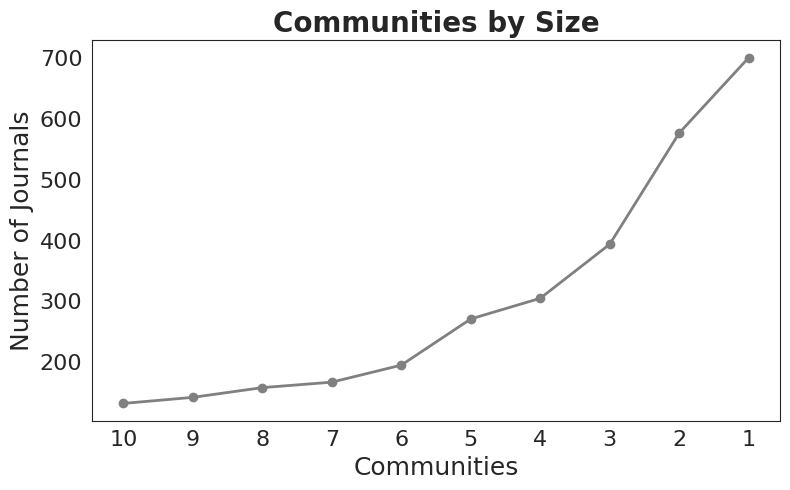

   community    n
0         10  132
1          9  142
2          8  158
3          7  167
4          6  195
5          5  271
6          4  305
7          3  394
8          2  577
9          1  701


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

G = journal_citation_graph_weighted_tbl_small

# Convertir nodos del grafo a DataFrame
nodes_df = pd.DataFrame(
    [{"node": n, **attrs} for n, attrs in G.nodes(data=True)]
)

if "community" not in nodes_df.columns:
    raise ValueError("El grafo no tiene atributo 'community' en los nodos.")

# Normalizar comunidad
nodes_df["community"] = pd.to_numeric(nodes_df["community"], errors="coerce")
nodes_df = nodes_df.dropna(subset=["community"]).copy()
nodes_df["community"] = nodes_df["community"].astype(int)

# Top 10 comunidades más grandes (tamaño real de cada comunidad)
community_counts = (
    nodes_df["community"]
    .value_counts()
    .rename_axis("community")
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(10)
)

# Ordenar para visualización como en tu ejemplo
community_counts = community_counts.sort_values("n", ascending=True).reset_index(drop=True)
community_counts["x_axis"] = range(len(community_counts))

# Plot
sns.set_style("white")
sns.despine()

plt.figure(figsize=(8, 5))
plt.plot(
    community_counts["x_axis"],
    community_counts["n"],
    marker="o",
    linestyle="-",
    color="gray",
    linewidth=2,
    markersize=6
)

plt.title("Communities by Size", fontsize=20, weight="bold")
plt.xlabel("Communities", fontsize=18)
plt.ylabel("Number of Journals", fontsize=18)

plt.xticks(community_counts["x_axis"], community_counts["community"], fontsize=16)
plt.yticks(fontsize=16)
plt.grid(False)
plt.tight_layout()

# Exportar en ruta actual (sin carpeta extra)
plt.savefig("figura_3b.svg", format="svg", dpi=300)
plt.show()

# Tabla de referencia
print(community_counts[["community", "n"]])


<Figure size 640x480 with 0 Axes>

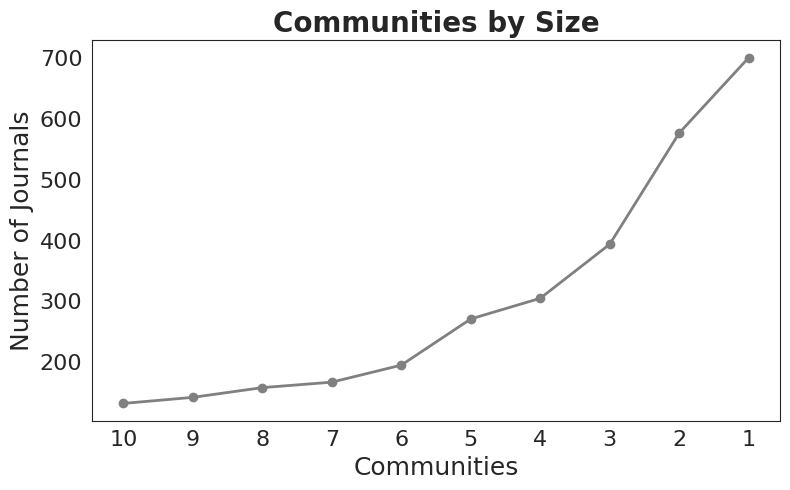

   community    n  x_axis
9         10  132       0
8          9  142       1
7          8  158       2
6          7  167       3
5          6  195       4
4          5  271       5
3          4  305       6
2          3  394       7
1          2  577       8
0          1  701       9


In [8]:
# Convertir nodos a DataFrame
nodes_df = pd.DataFrame.from_dict(dict(journal_citation_graph_weighted_tbl_small.nodes(data=True)), orient='index')
nodes_df['node'] = nodes_df.index
nodes_df.reset_index(drop=True, inplace=True)

nodes_df['community'] = nodes_df['community'].astype(int)

# Contar comunidades y seleccionar las 10 más grandes
community_counts = nodes_df['community'].value_counts().reset_index()
community_counts.columns = ['community', 'n']
community_counts = community_counts.sort_values('n', ascending=False).head(10)  # Tomar las 10 más grandes

# Ordenar de menor a mayor para la visualización
community_counts = community_counts.sort_values('n', ascending=True)

# Agregar un nuevo índice consecutivo
community_counts['x_axis'] = range(len(community_counts))

sns.set_style("white")
sns.despine()  # Elimina bordes superiores y derechos

plt.figure(figsize=(8, 5))

# Gráfico de línea con puntos
plt.plot(
    community_counts['x_axis'],
    community_counts['n'],
    marker='o',
    linestyle='-',
    color='gray',
    linewidth=2,
    markersize=6
)

# Personalizar estilo
plt.title("Communities by Size", fontsize=20, weight='bold')
plt.xlabel("Communities", fontsize=18)
plt.ylabel("Number of Journals", fontsize=18)

# Configurar etiquetas del eje x para mostrar los números de comunidad originales
plt.xticks(community_counts['x_axis'], community_counts['community'], fontsize=16)
plt.yticks(fontsize=16)

# Estilo adicional
plt.grid(False)
plt.tight_layout()

# Guardar como SVG (opcional)
plt.savefig('figura_3b.svg', format='svg')

plt.show()

# Mostrar la tabla de comunidades para referencia
print(community_counts)


Figure 3c Longitudinal

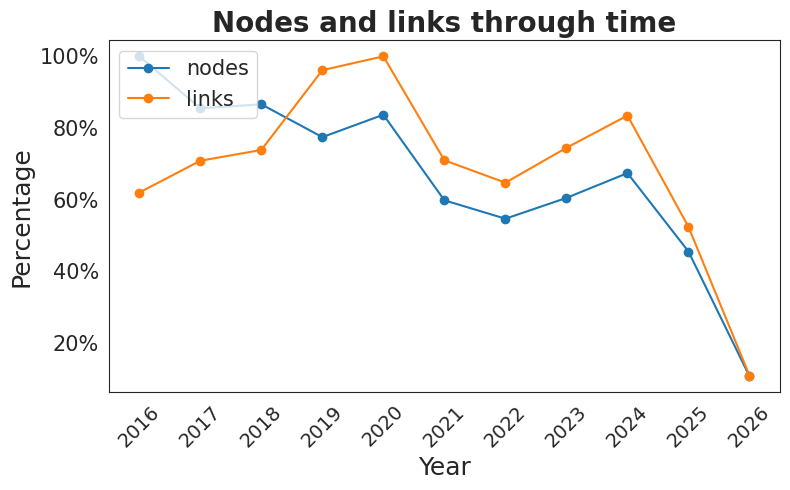

Saved: figura_3a.svg


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# -----------------------------
# Params
# -----------------------------
yearStart = 2016
yearEnd = 2026

# Usa el dataframe que ya cargaste desde Google Sheets
df = journal_df.copy()

# -----------------------------
# Detect columns (compatible con distintos nombres)
# -----------------------------
def pick_col(candidates, cols):
    for c in candidates:
        if c in cols:
            return c
    return None

from_col = pick_col(["from", "source_title_main"], df.columns)
to_col = pick_col(["to", "source_title_ref"], df.columns)
year_col = pick_col(["year", "SR_year", "year_main"], df.columns)

if from_col is None or to_col is None or year_col is None:
    raise ValueError(
        f"No encuentro columnas necesarias. "
        f"from={from_col}, to={to_col}, year={year_col}. "
        f"Columnas disponibles: {list(df.columns)}"
    )

# -----------------------------
# Clean
# -----------------------------
work = df[[from_col, to_col, year_col]].copy()
work.columns = ["from", "to", "year"]

for c in ["from", "to"]:
    work[c] = work[c].astype(str).str.strip()
    work.loc[work[c].str.lower().isin(["", "nan", "none", "null"]), c] = pd.NA

work["year"] = pd.to_numeric(work["year"], errors="coerce")
work = work.dropna(subset=["from", "to", "year"])
work["year"] = work["year"].astype(int)

# filtro rango
work = work[(work["year"] >= yearStart) & (work["year"] <= yearEnd)]

# quitar self-links
work_no_self = work[work["from"] != work["to"]].copy()

# -----------------------------
# Links through time
# -----------------------------
links = (
    work_no_self.groupby("year")
    .size()
    .reset_index(name="n")
)
links["percentage"] = links["n"] / links["n"].max() if len(links) else 0
links["type"] = "links"

# -----------------------------
# Nodes through time
# primer año de aparición de cada journal (from o to)
# -----------------------------
node_appearances = pd.concat(
    [
        work_no_self[["from", "year"]].rename(columns={"from": "node"}),
        work_no_self[["to", "year"]].rename(columns={"to": "node"}),
    ],
    ignore_index=True,
).drop_duplicates()

first_year = (
    node_appearances.groupby("node", as_index=False)["year"]
    .min()
)

nodes = (
    first_year.groupby("year")
    .size()
    .reset_index(name="n")
)
nodes["percentage"] = nodes["n"] / nodes["n"].max() if len(nodes) else 0
nodes["type"] = "nodes"

# -----------------------------
# Fill missing years
# -----------------------------
years = pd.DataFrame({"year": list(range(yearStart, yearEnd + 1))})

def fill_series(sdf, type_name):
    out = years.merge(sdf[["year", "percentage"]], on="year", how="left")
    out["percentage"] = out["percentage"].fillna(0)
    out["type"] = type_name
    return out

plot_df = pd.concat(
    [
        fill_series(nodes, "nodes"),
        fill_series(links, "links"),
    ],
    ignore_index=True
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))

for t in ["nodes", "links"]:
    d = plot_df[plot_df["type"] == t]
    plt.plot(d["year"], d["percentage"], marker="o", linestyle="-", label=t)

plt.title("Nodes and links through time", fontsize=20, weight="bold")
plt.ylabel("Percentage", fontsize=18)
plt.xlabel("Year", fontsize=18)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.yticks(fontsize=15)
plt.xticks(range(yearStart, yearEnd + 1), rotation=45, fontsize=14)

plt.gca().set_facecolor("white")
plt.legend(title=None, fontsize=15, loc="upper left")
plt.tight_layout()

plt.savefig("figura_3a.svg", format="svg", dpi=300)
plt.show()

print("Saved: figura_3a.svg")
